In [1]:
# Si estás en Google Colab o en un entorno donde PennyLane o networkx no están instalados, puedes usar los siguientes comandos para instalarlos:

!pip install pennylane
!pip install networkx

# Sesión 12 Laboratorio de Computación Cuántica 2

## Formulación QUBO y Transformación QUBO-Ising para Hamiltonianos

Ya que sabemos lo que es un Hamiltoniano, vamos a introducir a los conceptos necesarios para usar las herramientas que el VQE nos introdujo para trabajar con optimización de problemas combinatorios con aplicaciones en el mundo real.

## Clases de complejidad computacional

En teoría de la complejidad, los problemas se clasifican según qué tan difícil es resolverlos y verificarlos.

### Problemas $P$

Son los problemas que pueden resolverse eficientemente por una computadora clásica, es decir, en tiempo polinomial.

Si el tiempo de ejecución crece como

$$
n,\quad n^2,\quad n^3,\quad \dots
$$

entonces el problema pertenece a la clase $P$.

Ejemplos:
- Ordenar una lista
- Encontrar el camino más corto en un grafo
- Multiplicar matrices


### Problemas $NP$

Los problemas $NP$ son aquellos donde una solución propuesta puede verificarse eficientemente, aunque encontrarla pueda ser difícil.

Es decir:
- Encontrar la solución puede ser complicado.
- Verificar que una solución es correcta es rápido.

Ejemplo:
- Sudoku
- Traveling Salesman Problem (versión de decisión)
- Coloración de grafos


### Problemas NP-Hard

Un problema es **NP-Hard** si es al menos tan difícil como los problemas más difíciles de $NP$.

No necesariamente puede verificarse eficientemente ni siquiera pertenecer a $NP$.

Intuitivamente:
- Si resolvemos un problema NP-Hard eficientemente, podríamos resolver todos los problemas de $NP$ eficientemente.

Ejemplos:
- Traveling Salesman Problem
- Muchos problemas de optimización combinatoria


### Problemas NP-Complete

Son los problemas que cumplen dos condiciones:

1. Pertenecen a $NP$
2. También son NP-Hard

Es decir, son los problemas más difíciles dentro de $NP$.

Si algún problema NP-Complete pudiera resolverse en tiempo polinomial, entonces:

$$P = NP$$

Lo cual es uno de los problemas del milenio

Ejemplos clásicos:
- SAT
- 3-SAT
- Vertex Cover
- Coloración de grafos
- Hamiltonian Cycle


### Relación entre clases

$$
P \subseteq NP
$$

y dentro de $NP$ se encuentran los problemas NP-Complete.

Los problemas NP-Hard pueden incluso estar fuera de $NP$.

## Problemas Combinatorios



La rama de la matemática combinatoria nos presenta diversos desafíos interesantes con aplicaciones en el mundo real. Aquí presentare diversos problemas combinatorios y como entenderos y abordarlos para posteriormente, con la ayuda de la computación cuántica, encontrar formas de tajarlos.

## Teoría de Grafos (Introducción a Networkx)

Un grafo es una estructura matemática conformada por un conjunto de nodos (o vertices) y conexiones entre ellos llamadas aristas. Es un modelo muy sencillo, pero a partir de este modelo se derivan UNA INFINIDAD de problemas relacionados a optimización

Formalmente, un grafo se identifica como G=(V,E) donde V son los vertices y E son las aristas (edges)


Estos permiten representar relaciones y redes, por lo que son una herramienta fundamental para modelar sistemas con aplicaciones reales. 

Aquí veremos 3 problemas principales que se pueden abordar con esto:

1. Problema de Coloración
2. Max-cut
3. Traveling Salesman/Problema del Viajero

Para poder abordarlos, daremos una introducción intuitiva a los mismos utilizando la librería Networkx

Crearemos un grafo simple:

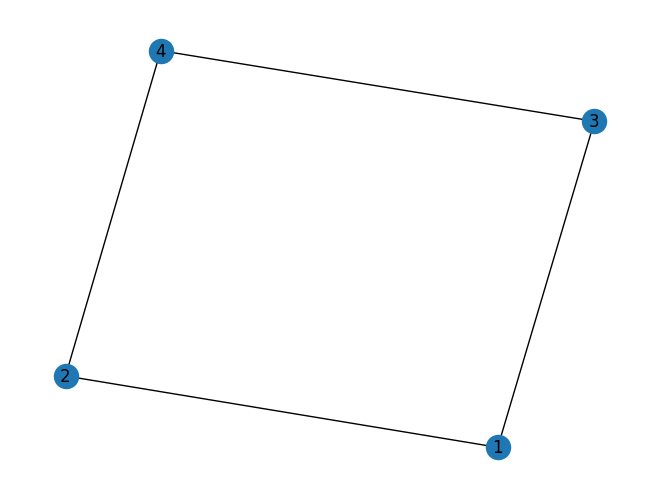

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()   #Fabricamos el espacio de grafos

# Agregamos nodos
G.add_nodes_from([1, 2, 3, 4])

# Agregamos conexiones
G.add_edges_from([
    (1, 2),
    (1, 3),
    (2, 4),
    (3, 4)
])

nx.draw(G, with_labels=True)  #Dibujamos el grafo (Usa with labels=True para mostrar los números de los nodos)
plt.show()

No es necesario agregar los vertices, si tu agregas las aristas automáticamente, los vértices se crean

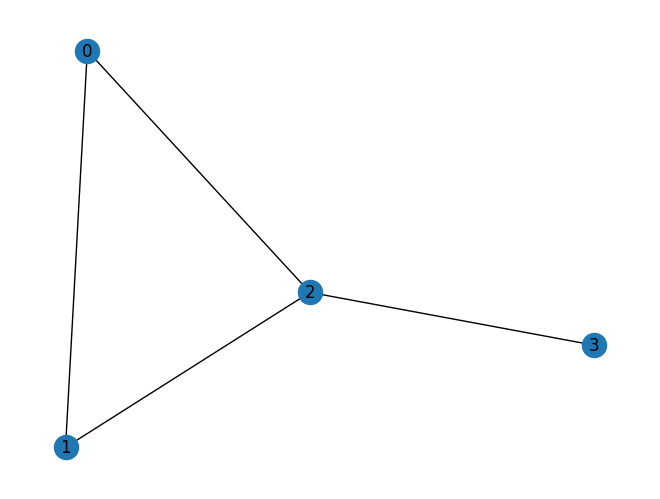

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

G.add_edges_from([#Agregamos conexiones
    (0, 1),
    (0, 2),
    (1, 2),
    (2, 3)
])

pos = nx.spring_layout(G) #Calculamos la posición de los nodos usando el algoritmo de disposición de resorte

nx.draw(G, pos, with_labels=True) #Dibujamos el grafo usando las posiciones calculadas

plt.show() #Mostramos el grafo

In [4]:
print(G.nodes()) #Imprime los nodos del grafo
print(G.edges()) #Imprime las conexiones del grafo
print(list(G.neighbors(1))) #Imprime los vecinos del nodo 1, es decir, los nodos conectados a él

[0, 1, 2, 3]
[(0, 1), (0, 2), (1, 2), (2, 3)]
[0, 2]


### Problema de Coloración de Grafos

Imagina que te dan un grafo y te dicen "Vas a colorear cada uno de los nodos" de manera que no hayan 2 nodos conectados que tengan el mismo color. La pregunta es ¿Cuantos colores necesitas para poder colorear a este grafo? El número mínimo de colores que necesitas se le conoce como el número cromático. El problema de coloración de grafos te pide que colorees el grafo de manera que uses el mínimo de colores posibles para ello y expongas la coloración del grafo en si mismo.

Este es un problema NP-Hard, usaremos networkx para visualizarlo. Si deseas entrar en mas detalles al respecto, puedes indagar en el código con mas detalle


In [5]:
G = nx.Graph()

G.add_edges_from([
    (0, 1),
    (0, 2),
    (1, 2),
    (1, 3),
    (2, 4),
    (3, 4)
])

In [6]:
coloring = nx.coloring.greedy_color(G)

print(coloring) #Imprime el resultado del coloreo, donde cada nodo se asigna a un color representado por un número entero.

{1: 0, 2: 1, 0: 2, 3: 1, 4: 0}


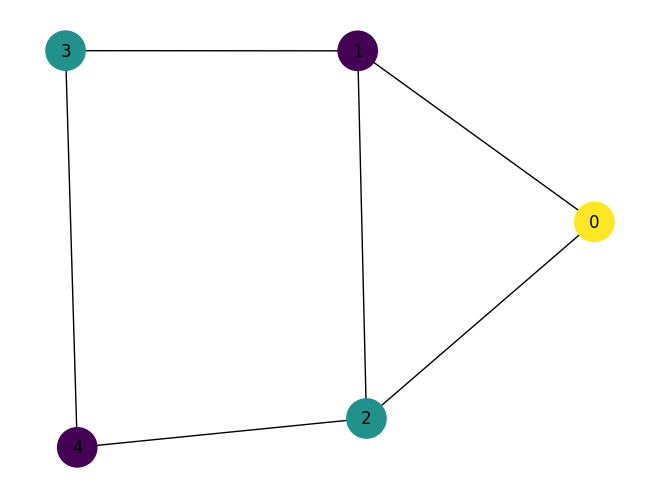

In [7]:
pos = nx.spring_layout(G, seed=42)

node_colors = [coloring[node] for node in G.nodes()]

nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=800)

plt.show()

El approach de Networkx para este tipo de problemas es el Greedy Color. Esta técnica es una técnica clásica que consiste en encontrar una forma de colorear de forma "a fuerza bruta", es decir, va nodo por nodo y colorea en función de sus conexiones. Si puede usar un color disponible, lo usa, si no, genera un nuevo color.

### Problema del Max-Cut o corte mas grande

Supongamos que tenemos un grafo. Este grafo tiene varios nodos y aristas. Entonces te encomiendo una misión: Divide los vértices en 2 conjuntos disjuntos (es decir, que no exista ningún elemento que este en ambos conjuntos) pero cada vértice debe estar en alguno de los 2 conjuntos. ¿Cuantas aristas conectan los 2 conjuntos entre si? Son muchas, de manera que podemos imaginar que hay una linea que parte en 2 al grafo y lo secciona. A este concepto se le conoce como corte, o cut en ingles. 

El problema del Max-cut basicamente nos dice "Busca el corte que tenga la mayor cantidad de aristas entre los 2 conjuntos". Esto es el Max-Cut. Y es un problema que escala muy mal, debido a que para n nodos, tienes un total de $2^n$ posibles cortes **(Pregunta: ¿Por que?)** lo cual nos da una complejidad exponencial del problema. 

Es un problema NP-Hard

Visualicemos un ejemplo de este problema en Networkx

In [8]:
G = nx.Graph()

G.add_edges_from([
    (0, 1),
    (0, 2),
    (0, 3),
    (1, 2),
    (1, 3),
    (2, 3)
])

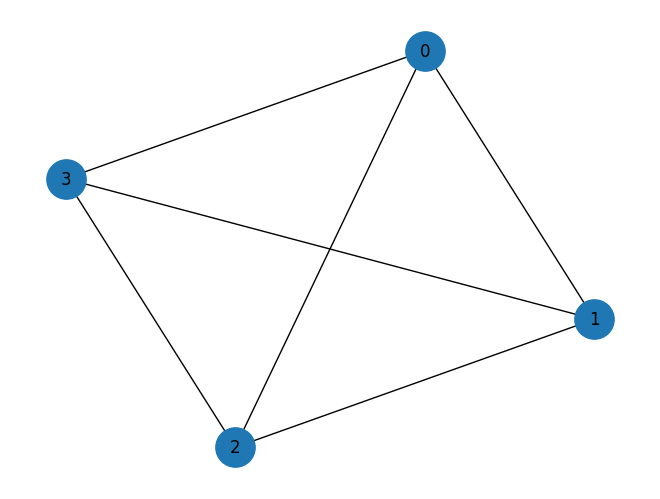

In [9]:
pos = nx.spring_layout(G, seed=42)

nx.draw(G, pos, with_labels=True, node_size=800)

plt.show()

Vamos a proponer un corte para asignar los vértices en 2 grupos. Utilizaremos un diccionario

In [10]:
assignment = {0: 0, 1: 1, 2: 1, 3: 0}

Veamos el valor del corte que tenemos aquí (es decir, cuantas aristas corta)

In [11]:
cut_value = 0 #Inicializamos el valor del corte a cero

for u, v in G.edges(): #Iteramos sobre cada conexión del grafo, es decir, cada par de nodos conectados por una arista
    if assignment[u] != assignment[v]: #Si los nodos conectados tienen asignaciones diferentes, significa que la conexión cruza el corte
        cut_value += 1 #Incrementamos el valor del corte por cada conexión que cruza el corte

print("Valor del corte:", cut_value) #Imprime el valor del corte, que es el número de conexiones que cruzan el corte definido por la asignación dada.

Valor del corte: 4


Vamos a visualizar el corte con la ayuda de diversas herramientas

In [12]:
node_colors = [] #Creamos una lista para almacenar los colores de los nodos según su asignación

for node in G.nodes(): #Iteramos sobre los nodos
    if assignment[node] == 0: #Si la asignación del nodo es 0, lo coloreamos de azul claro
        node_colors.append("lightblue")
    else: #Si la asignación del nodo es 1, lo coloreamos de coral claro
        node_colors.append("lightcoral")

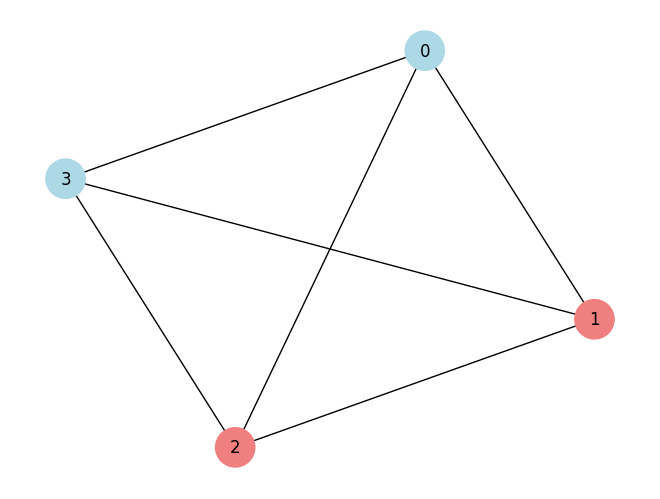

In [13]:
nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=800)

plt.show()

Y para visualizar las aristas:

In [14]:
cut_edges = [] #Creamos una lista para almacenar las conexiones que cruzan el corte
non_cut_edges = [] #Creamos una lista para almacenar las conexiones que no cruzan el corte

for u, v in G.edges(): #Iteramos sobre cada conexión del grafo
    if assignment[u] != assignment[v]:
        cut_edges.append((u, v)) #Si los nodos conectados tienen asignaciones diferentes, agregamos la conexión a la lista de conexiones que cruzan el corte
    else:
        non_cut_edges.append((u, v)) #Si los nodos conectados tienen asignaciones iguales, agregamos la conexión a la lista de conexiones que no cruzan el corte

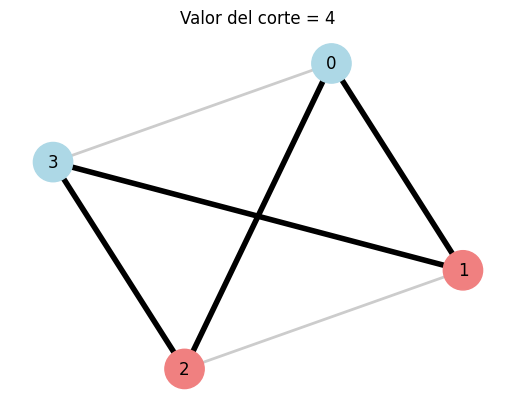

In [15]:
nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=800
)

# Dibujamos etiquetas
nx.draw_networkx_labels(
    G,
    pos
)

# Dibujamos aristas que NO cruzan el corte
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=non_cut_edges,
    alpha=0.2,
    width=2 #Mas delgadas
)

# Dibujamos aristas que SÍ cruzan el corte
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=cut_edges,
    width=4 #Más gruesas para resaltar las conexiones que cruzan el corte
)

plt.title(f"Valor del corte = {cut_value}")
plt.axis("off")
plt.show()

Para facilitarte las cosas y puedas usar este código a tu preferencia, lo encapsulé en una función que te permite evaluar el corte que tu elegiste para que puedas trabajar con el

In [16]:
def calcular_valor_corte(G, assignment):
    cut_value = 0

    for u, v in G.edges():
        if assignment[u] != assignment[v]:
            cut_value += 1

    return cut_value

In [17]:
corte = calcular_valor_corte(G, assignment)

print("Valor del corte:", corte)

Valor del corte: 4


Para facilitarte la visualización de los cortes y no perder el hilo de la clase, te dejo la función con la que puedes trabajar para que se vea el corte que aplicaste

In [18]:
def draw_cut(G, assignment):
    pos = nx.spring_layout(G, seed=42)

    cut_edges = []
    non_cut_edges = []

    for u, v in G.edges():
        if assignment[u] != assignment[v]:
            cut_edges.append((u, v))
        else:
            non_cut_edges.append((u, v))

    node_colors = []

    for node in G.nodes():
        if assignment[node] == 0:
            node_colors.append("lightblue")
        else:
            node_colors.append("lightcoral")

    cut_value = calcular_valor_corte(G, assignment)

    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=node_colors,
        node_size=800
    )

    nx.draw_networkx_labels(
        G,
        pos
    )

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=non_cut_edges,
        alpha=0.2,
        width=2
    )

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=cut_edges,
        width=4
    )

    plt.title(f"Valor del corte = {cut_value}")
    plt.axis("off")
    plt.show()

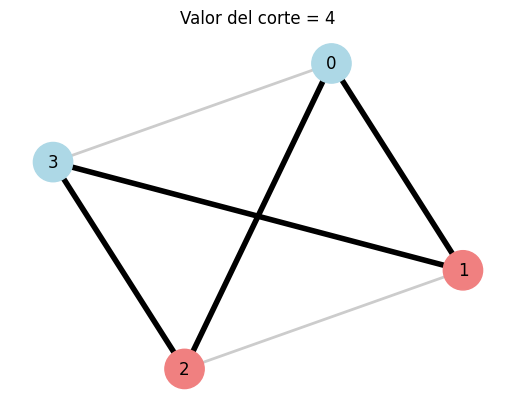

In [19]:
draw_cut(G, assignment)

Para poder calcular el Max-Cut con Fuerza bruta, podemos evaluar en todas las $2^n$ asignaciones y con ello poder encontrar el valor del corte máximo y su asignación correspondiente. Te dejo una funcion que hace esto rapidamente. No explicare su funcionamiento y no sera necesario para el proposito de este curso, pero la dejare debidamente documentada para que tu puedas entender como funciona si te interesa entrar mas a fondo en el area

In [20]:
import itertools #Importamos la biblioteca itertools para generar todas las combinaciones posibles de asignaciones de nodos

def max_cut_fuerza_bruta(G): 
    nodes = list(G.nodes()) #Obtenemos la lista de nodos del grafo para poder iterar sobre ellos y generar las asignaciones de corte

    best_value = -1 #Inicializamos el mejor valor del corte a -1, lo que significa que aún no hemos encontrado ningún corte válido
    best_assignment = None #Inicializamos la mejor asignación a None, lo que significa que aún no hemos encontrado ninguna asignación válida

    for bits in itertools.product([0, 1], repeat=len(nodes)): #Generamos todas las combinaciones posibles de asignaciones de nodos (0 o 1) para cada nodo en el grafo
        assignment = dict(zip(nodes, bits)) #Creamos un diccionario que asigna cada nodo a su correspondiente bit (0 o 1) en la combinación actual
        value = calcular_valor_corte(G, assignment) #Calculamos el valor del corte para la asignación actual utilizando la función calcular_valor_corte que definimos anteriormente

        if value > best_value: #Si el valor del corte para la asignación actual es mejor que el mejor valor encontrado hasta ahora, actualizamos el mejor valor y la mejor asignación
            best_value = value #Actualizamos el mejor valor del corte encontrado hasta ahora
            best_assignment = assignment #Actualizamos la mejor asignación encontrada hasta ahora

    return best_value, best_assignment #Devolvemos el mejor valor del corte encontrado y la asignación correspondiente que produce ese corte.

In [21]:
best_value, best_assignment = max_cut_fuerza_bruta(G)

print("Mejor valor encontrado:", best_value)
print("Mejor asignación:", best_assignment)

Mejor valor encontrado: 4
Mejor asignación: {0: 0, 1: 0, 2: 1, 3: 1}


### Traveling Salesman/El problema del viajero



Este es el problema de optimización combinatoria mas popular y mas común cuando se trata de explicar todo esto. Imagina que eres un viajero que tiene que recorrer varias ciudades, de manera que tengas que pasar por todas las ciudades y regresar a la que iniciaste, recorriendo la menor distancia posible. 

Este problema usa un grafo pesado, es decir, un grafo cuyas aristas tienen ademas valores de distancia cada una. En lenguaje formal, lo que buscamos es un ciclo Hamiltoniano de los grafos, es decir, un camino que pase por todos los vértices y regrese a su punto inicial. Pero para ello, buscamos que este camino sea "de costo minimo", es decir, el que sea menos costoso para el viajero. 

Este problema no escala de forma exponencial, si no de forma logaritmica. Si tienes n ciudades, tendras un total de $(n-1)!$ rutas posibles a recorrer, lo cual hace que este problema sea un problema complicado

Visualicemos en Networkx este problema

In [22]:
ciudades = { #Definimos un diccionario que representa las ciudades y sus coordenadas en un plano cartesiano
    0: (0, 0),
    1: (1, 3),
    2: (4, 3),
    3: (5, 1),
    4: (2, -1)
}

Dado que asumimos que se puede viajar de cualquier ciudad a cualquier otra (Esto en la práctica NO SIEMPRE ES CIERTO pero podemos asumirlo), se crea un tipo de grafo al que llamaremos *Grafo Completo*, que es precisamente un grado donde todos los nodos estan conectados por todos los otros nodos.

In [23]:
G = nx.complete_graph(len(ciudades)) #Creamos un grafo completo con el número de nodos igual al número de ciudades

In [24]:
import numpy as np

for i, j in G.edges():
    xi, yi = ciudades[i] #Obtenemos las coordenadas de la ciudad i
    xj, yj = ciudades[j] #Obtenemos las coordenadas de la ciudad j

    distancia = np.sqrt((xi - xj)**2 + (yi - yj)**2)

    G[i][j]["weight"] = distancia

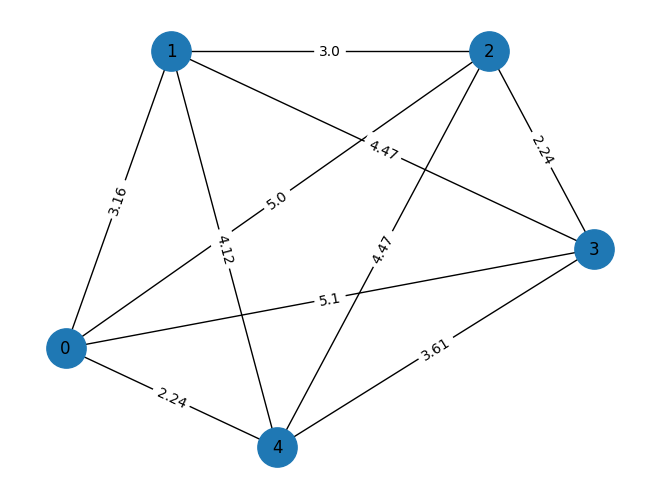

In [25]:
pos = ciudades #Usamos las coordenadas de las ciudades como posiciones para los nodos en el grafo

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=800
)

edge_labels = {}

for i, j in G.edges():
    edge_labels[(i, j)] = round(G[i][j]["weight"], 2) #Redondeamos el peso de cada conexión a 2 decimales para que las etiquetas sean más legibles

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)

plt.show()

## La formulación QUBO

Hasta ahora hemos visto varios problemas de optimización combinatoria, pero todos son en esencia lo mismo: 

>Optimizar un problema de variables discretas. 

Y a diferencia de las variables continuas donde podemos derivar, aquí no podemos hacer eso. Pero existe una forma de unificar las representaciones de estas variables, se les conoce como la formulación QUBO.

QUBO significa:

$$
\text{Quadratic Unconstrained Binary Optimization}
$$

es decir:

$$
\text{Optimización Binaria Cuadrática sin Restricciones}
$$

Vamos a entender cada una de las partes

Un problema QUBO tiene tres ingredientes importantes:

1. **Binary:** las variables solo pueden tomar los valores $0$ o $1$.
2. **Quadratic:** la función objetivo puede tener términos lineales y términos cuadráticos.
3. **Unconstrained:** no escribimos restricciones por separado, todo se incluye dentro de una sola función de costo.

y la función de costo es EL EJE detrás de todo esto. Es la parte mas importante

La forma general de un problema QUBO es la siguiente:
$$
\min_{x \in \{0,1\}^n} x^T Q x
$$

donde:

- $x$ es un vector de variables binarias,
- $Q$ es una matriz que contiene los coeficientes del problema,
- el objetivo es encontrar la asignación binaria $x$ que minimiza la función.

### Knapsack Problem/El problema de la mochila

Nuestra introducción a QUBO va a partir de el problema de la mochila, y a partir de ahí lo generalizaremos al resto de problemas que hemos visto de una forma muy elegante. Vamos a por ello

El **Knapsack Problem**, o problema de la mochila, es un problema clásico de optimización combinatoria.

Tenemos una mochila con una capacidad máxima de peso. También tenemos varios objetos, y cada objeto tiene:

- un peso,
- un valor.

El objetivo es elegir qué objetos meter en la mochila para maximizar el valor total, sin exceder la capacidad máxima.

#### Ejemplo

Supongamos que tenemos tres objetos:

| Objeto | Peso | Valor |
|---|---:|---:|
| 1 | 2 | 6 |
| 2 | 3 | 8 |
| 3 | 4 | 11 |

La capacidad máxima de la mochila es:

$$
W = 5
$$

Queremos elegir objetos de tal forma que el valor total sea lo más grande posible, pero sin que el peso total supere $5$.

#### Variables Binarias

Asignamos una variable binaria a cada objeto:

$$
x_i \in \{0,1\}
$$

donde:

$$
x_i =
\begin{cases}
1, & \text{si tomamos el objeto } i,\\
0, & \text{si no tomamos el objeto } i.
\end{cases}
$$

Por ejemplo:

$$
x = (1,0,1)
$$

significa que tomamos los objetos 1 y 3, pero no tomamos el objeto 2.

### Valor total

Si cada objeto tiene valor $v_i$, entonces el valor total de una selección es:

$$
\sum_i v_i x_i
$$

Para nuestro ejemplo:

$$
v_1 = 6, \qquad v_2 = 8, \qquad v_3 = 11.
$$

Por lo tanto, el valor total es:

$$
6x_1 + 8x_2 + 11x_3.
$$

Como queremos objetos valiosos, el problema original busca maximizar esta cantidad. y QUBO es una formulación asociada a una función de costo, de manera que esto lo tendremos como signo negativo, por lo cual la representación de la función de costo quedara como

$$
-6x_1-8x_2-11x_3
$$

### Peso total

Si cada objeto tiene peso $w_i$, entonces el peso total de una selección es:

$$
\sum_i w_i x_i.
$$

Para nuestro ejemplo:

$$
w_1 = 2, \qquad w_2 = 3, \qquad w_3 = 4.
$$

Entonces el peso total es:

$$
2x_1 + 3x_2 + 4x_3.
$$

La mochila tiene capacidad máxima:

$$
W = 5.
$$

Por lo tanto, la restricción es:

$$
2x_1 + 3x_2 + 4x_3 \leq 5.
$$

### Restricciones como penalizaciones

El problema original de la mochila tiene una restricción:

$$
2x_1 + 3x_2 + 4x_3 \leq 5.
$$

Sin embargo, un problema QUBO no trabaja con restricciones explícitas. En QUBO queremos escribir todo dentro de una sola función objetivo.

La idea es convertir la restricción en una penalización.

Como queremos maximizar el valor de los objetos, pero QUBO se formula como minimización, primero escribimos:

$$
-\left(6x_1 + 8x_2 + 11x_3\right).
$$

Después agregamos un término que castigue las soluciones que exceden la capacidad de la mochila:

$$
P\left(2x_1 + 3x_2 + 4x_3 - 5\right)^2.
$$

Entonces una función de costo tipo QUBO para visualizar el problema es:

$$
C(x)
=
-\left(6x_1 + 8x_2 + 11x_3\right)
+
P\left(2x_1 + 3x_2 + 4x_3 - 5\right)^2.
$$

El primer término favorece elegir objetos de alto valor.

El segundo término penaliza selecciones cuyo peso se aleja de la capacidad máxima.

Aquí $P > 0$ controla qué tan fuerte es la penalización. Si $P$ es grande, las soluciones que no respetan la capacidad reciben un costo alto.

En esta sección usaremos esta función para visualizar cómo una restricción puede incorporarse dentro de una función de costo QUBO.

> Nota: La restricción real del problema de la mochila es una desigualdad. Existen formulaciones QUBO más cuidadosas para tratar desigualdades, pero aquí usaremos esta penalización simple para visualizar la idea central: convertir restricciones en términos de costo.

### Forma matricial de QUBO

Una vez que tenemos una función de costo escrita con variables binarias, podemos representarla usando una matriz.

Recordemos que la forma general de un problema QUBO es:

$$
\min_{x \in \{0,1\}^n} x^T Q x.
$$

Aquí:

- $x$ es un vector de variables binarias.
- $Q$ es una matriz que contiene los coeficientes de la función objetivo.
- El objetivo es encontrar la asignación de $x$ que minimiza el valor de $x^TQx$.

Para trabajar de forma sencilla, usaremos la matriz $Q$ en su forma triangular superior:

$$
Q =
\begin{pmatrix}
Q_{11} & Q_{12} & Q_{13} & \cdots \\
0 & Q_{22} & Q_{23} & \cdots \\
0 & 0 & Q_{33} & \cdots \\
\vdots & \vdots & \vdots & \ddots
\end{pmatrix}.
$$

En esta convención:

- los coeficientes lineales se colocan en la diagonal,
- los coeficientes cuadráticos se colocan fuera de la diagonal.

### ¿Por qué los términos lineales van en la diagonal?

En QUBO, las variables son binarias:

$$
x_i \in \{0,1\}.
$$

Por lo tanto, cumplen la propiedad:

$$
x_i^2 = x_i.
$$

Esto ocurre porque:

- si $x_i = 0$, entonces $x_i^2 = 0$,
- si $x_i = 1$, entonces $x_i^2 = 1$.

Por eso, un término lineal como:

$$
-6x_1
$$

puede escribirse como:

$$
-6x_1^2.
$$

Y como $x_1^2$ aparece en la entrada diagonal de $x^TQx$, colocamos ese coeficiente en $Q_{11}$.

### Llenado de la matriz Q

Supongamos que operamos la función del knapsack problem y entonces tenemos una función QUBO de la forma:

$$
f(x_1,x_2,x_3)
=
-6x_1 - 8x_2 - 11x_3
+ 4x_1x_2
+ 7x_1x_3
+ 3x_2x_3.
$$

Los términos lineales son:

$$
-6x_1, \qquad -8x_2, \qquad -11x_3.
$$

Como $x_i^2 = x_i$, los colocamos en la diagonal:

$$
Q_{11} = -6, \qquad Q_{22} = -8, \qquad Q_{33} = -11.
$$

Los términos cuadráticos son:

$$
4x_1x_2, \qquad 7x_1x_3, \qquad 3x_2x_3.
$$

Por lo tanto, los colocamos fuera de la diagonal:

$$
Q_{12} = 4, \qquad Q_{13} = 7, \qquad Q_{23} = 3.
$$

Así, la matriz Q queda:

$$
Q =
\begin{pmatrix}
-6 & 4 & 7 \\
0 & -8 & 3 \\
0 & 0 & -11
\end{pmatrix}.
$$

## QUBO en Max-cut, Coloración y Viajero

### Formulación QUBO de Max-Cut

En Max-Cut queremos separar los nodos de un grafo en dos grupos, de forma que el mayor número posible de aristas conecte nodos en grupos distintos.

Asignamos una variable binaria a cada nodo:

$$
x_i \in \{0,1\}
$$

donde $x_i$ indica en qué grupo colocamos al nodo $i$.

Para una arista $(i,j)$, esta arista cruza el corte si los nodos están en grupos diferentes:

$$
x_i \neq x_j.
$$

Una forma de escribir esto algebraicamente es:

$$
x_i + x_j - 2x_ix_j.
$$

Esta expresión vale:

- $1$ si $x_i$ y $x_j$ son diferentes,
- $0$ si $x_i$ y $x_j$ son iguales.

Por lo tanto, el valor del corte es:

$$
C(x) = \sum_{(i,j)\in E} \left(x_i + x_j - 2x_ix_j\right).
$$

Como Max-Cut busca maximizar el número de aristas cortadas, pero QUBO se escribe como minimización, usamos:

$$
\min_x \; -\sum_{(i,j)\in E} \left(x_i + x_j - 2x_ix_j\right).
$$

Esta expresión ya es cuadrática y binaria, por lo que puede escribirse como un QUBO.

### Ejemplo sencillo: Max-Cut

Consideremos un triángulo con nodos $1,2,3$ y aristas:

$$
E = \{(1,2),(1,3),(2,3)\}.
$$

La función de corte es:

$$
C(x)
=
(x_1+x_2-2x_1x_2)
+
(x_1+x_3-2x_1x_3)
+
(x_2+x_3-2x_2x_3).
$$

Agrupando términos:

$$
C(x)
=
2x_1 + 2x_2 + 2x_3
-2x_1x_2
-2x_1x_3
-2x_2x_3.
$$

Como queremos maximizar $C(x)$, escribimos el QUBO como:

$$
\min_x
\;
-2x_1 -2x_2 -2x_3
+2x_1x_2
+2x_1x_3
+2x_2x_3.
$$

La matriz QUBO triangular superior es:

$$
Q =
\begin{pmatrix}
-2 & 2 & 2 \\
0 & -2 & 2 \\
0 & 0 & -2
\end{pmatrix}.
$$

Este QUBO penaliza que nodos conectados queden en el mismo grupo y favorece que queden en grupos opuestos.

### Formulación QUBO del Traveling Salesman Problem

En el Traveling Salesman Problem queremos encontrar la ruta más corta que visite todas las ciudades exactamente una vez y regrese al punto inicial.

A diferencia de Max-Cut, aquí no basta con una variable por ciudad. Necesitamos saber qué ciudad está en qué posición de la ruta.

Definimos variables binarias:

$$
x_{i,t} \in \{0,1\}
$$

donde:

$$
x_{i,t} =
\begin{cases}
1, & \text{si la ciudad } i \text{ se visita en la posición } t,\\
0, & \text{si no.}
\end{cases}
$$

Para $n$ ciudades, tenemos aproximadamente $n^2$ variables binarias.

La función QUBO tiene tres partes:

1. **Costo de viaje:** suma las distancias entre ciudades consecutivas.
2. **Restricción de ciudad única:** cada ciudad debe aparecer exactamente una vez.
3. **Restricción de posición única:** en cada posición de la ruta debe haber exactamente una ciudad.

El costo de viaje puede escribirse como:

$$
\sum_t \sum_{i,j} d_{ij} x_{i,t}x_{j,t+1},
$$

donde $d_{ij}$ es la distancia entre la ciudad $i$ y la ciudad $j$.

Las restricciones se agregan como penalizaciones cuadráticas.

La idea general es:

$$
C(x) =
\text{distancia total}
+
\text{penalizaciones}.
$$

Minimizar este QUBO busca una ruta corta que además respete las reglas del TSP.

### Ejemplo sencillo: TSP

Supongamos que tenemos tres ciudades:

$$
A, B, C.
$$

Una posible ruta sería:

$$
A \to B \to C \to A.
$$

Para escribir esto en forma binaria, usamos variables:

$$
x_{A,1}, x_{A,2}, x_{A,3},
$$

$$
x_{B,1}, x_{B,2}, x_{B,3},
$$

$$
x_{C,1}, x_{C,2}, x_{C,3}.
$$

Por ejemplo, la ruta:

$$
A \to B \to C
$$

se representa como:

$$
x_{A,1}=1,\qquad x_{B,2}=1,\qquad x_{C,3}=1.
$$

Todas las demás variables valen $0$.

La parte de costo mide las distancias entre ciudades consecutivas:

$$
d_{AB}x_{A,1}x_{B,2}
+
d_{BC}x_{B,2}x_{C,3}
+
d_{CA}x_{C,3}x_{A,1}.
$$

Además se agregan penalizaciones para evitar soluciones inválidas, por ejemplo:

- que una ciudad aparezca dos veces,
- que una posición tenga dos ciudades,
- que una ciudad no aparezca.

El TSP tiene una formulación QUBO más pesada que Max-Cut porque requiere variables por ciudad y por posición.

### Formulación QUBO de coloración de grafos

En el problema de coloración queremos asignar colores a los nodos de un grafo de manera que dos nodos conectados no tengan el mismo color.

Supongamos que tenemos $k$ colores disponibles.

Usamos variables binarias:

$$
x_{i,c} \in \{0,1\}
$$

donde:

$$
x_{i,c} =
\begin{cases}
1, & \text{si el nodo } i \text{ tiene color } c,\\
0, & \text{si no.}
\end{cases}
$$

La formulación QUBO debe imponer dos ideas:

1. Cada nodo debe tener exactamente un color.
2. Dos nodos conectados no deben compartir el mismo color.

La primera condición se puede penalizar con:

$$
\sum_i \left(1 - \sum_c x_{i,c}\right)^2.
$$

La segunda condición se penaliza con:

$$
\sum_{(i,j)\in E}\sum_c x_{i,c}x_{j,c}.
$$

Este segundo término aumenta el costo cuando dos nodos conectados tienen el mismo color.

La función QUBO tiene la forma:

$$
C(x)
=
A\sum_i \left(1 - \sum_c x_{i,c}\right)^2
+
B\sum_{(i,j)\in E}\sum_c x_{i,c}x_{j,c}.
$$

Minimizar esta función busca una coloración válida.

### Ejemplo sencillo: coloración de grafos

Supongamos que tenemos dos nodos conectados:

$$
1 - 2
$$

y dos colores posibles:

$$
R, B.
$$

Usamos las variables:

$$
x_{1,R}, x_{1,B}, x_{2,R}, x_{2,B}.
$$

La condición de que cada nodo tenga un solo color se penaliza como:

$$
\left(1 - x_{1,R} - x_{1,B}\right)^2
+
\left(1 - x_{2,R} - x_{2,B}\right)^2.
$$

La condición de que nodos conectados no compartan color se penaliza como:

$$
x_{1,R}x_{2,R}
+
x_{1,B}x_{2,B}.
$$

Entonces una función QUBO sencilla es:

$$
C(x)
=
A\left(1 - x_{1,R} - x_{1,B}\right)^2
+
A\left(1 - x_{2,R} - x_{2,B}\right)^2
+
B\left(x_{1,R}x_{2,R}
+
x_{1,B}x_{2,B}\right).
$$

Si ambos nodos reciben el mismo color, el costo aumenta.

Si cada nodo tiene exactamente un color y además son colores distintos, el costo es bajo.

***Detente aquí, tomate un cafe, come un chocolate, relajate, por que se va a desmadrar la cosa***

## Transformación QUBO a Modelo Ising

Hasta ahora escribimos problemas de optimización en forma QUBO:

$$
\min_{x \in \{0,1\}^n} x^T Q x.
$$

En esta formulación, las variables son binarias:

$$
x_i \in \{0,1\}.
$$

Sin embargo, en física y en computación cuántica es muy común trabajar con variables tipo espín:

$$
s_i \in \{-1,1\}.
$$

La formulación de Ising escribe el problema como una función de energía en términos de estos espines.

### Hamiltoniano de Ising

El Hamiltoniano de Ising tiene la forma:

$$
H(s)
=
\sum_i h_i s_i
+
\sum_{i<j} J_{ij}s_i s_j.
$$

Aquí:

- $s_i \in \{-1,1\}$ representa un espín clásico.
- $h_i$ es un campo local que favorece $s_i = 1$ o $s_i = -1$.
- $J_{ij}$ representa una interacción entre los espines $i$ y $j$.

El objetivo es encontrar la configuración de espines que minimiza la energía:

$$
\min_{s \in \{-1,1\}^n} H(s).
$$

Como ya vieron VQE, es la misma lógica, transformar un problema QUBO a un problema Ising, y encontrar su estado base

### De variables binarias a espines

Para transformar un QUBO en un modelo de Ising necesitamos cambiar variables binarias:

$$
x_i \in \{0,1\}
$$

por variables de espín:

$$
s_i \in \{-1,1\}.
$$

La transformación estándar es:

$$
x_i = \frac{1+s_i}{2}.
$$

Esto funciona porque:

- si $s_i = -1$, entonces

$$
x_i = \frac{1+(-1)}{2} = 0,
$$

- si $s_i = 1$, entonces

$$
x_i = \frac{1+1}{2} = 1.
$$

También podemos escribir la transformación inversa:

$$
s_i = 2x_i - 1.
$$

### Transformación QUBO a Ising

Supongamos que tenemos un QUBO escrito como:

$$
C(x)
=
\sum_i Q_{ii}x_i
+
\sum_{i<j}Q_{ij}x_ix_j.
$$

Para pasarlo a Ising, sustituimos:

$$
x_i = \frac{1+s_i}{2}.
$$

Entonces:

$$
x_ix_j
=
\frac{1+s_i}{2}
\frac{1+s_j}{2}
=
\frac{1+s_i+s_j+s_is_j}{4}.
$$

Después de sustituir y agrupar términos, la función queda con la forma:

$$
H(s)
=
\text{constante}
+
\sum_i h_i s_i
+
\sum_{i<j} J_{ij}s_i s_j.
$$

La constante no cambia qué configuración minimiza la energía, pero sí desplaza el valor total de la energía.

### Ejemplo sencillo

Consideremos el QUBO:

$$
C(x_1,x_2)
=
-3x_1 - 2x_2 + 4x_1x_2.
$$

Usamos:

$$
x_1 = \frac{1+s_1}{2},
\qquad
x_2 = \frac{1+s_2}{2}.
$$

Sustituimos:

$$
C(s_1,s_2)
=
-3\left(\frac{1+s_1}{2}\right)
-2\left(\frac{1+s_2}{2}\right)
+
4\left(\frac{1+s_1}{2}\right)
\left(\frac{1+s_2}{2}\right).
$$

Expandimos:

$$
C(s_1,s_2)
=
-\frac{3}{2}
-\frac{3}{2}s_1
-1
-s_2
+
(1+s_1+s_2+s_1s_2).
$$

Agrupando términos:

$$
C(s_1,s_2)
=
-\frac{3}{2}
-\frac{1}{2}s_1
+
0s_2
+
s_1s_2.
$$

Entonces el Hamiltoniano de Ising equivalente es:

$$
H(s_1,s_2)
=
-\frac{1}{2}s_1
+
s_1s_2
-
\frac{3}{2}.
$$

La constante no es relevante, pues buscar minimizar la función

### De Ising a Hamiltoniano cuántico

Para llevar el modelo de Ising a un Hamiltoniano cuántico, reemplazamos cada variable de espín $s_i$ por un operador de Pauli $Z_i$.

Recordemos que:

$$
Z =
\begin{pmatrix}
1 & 0 \\
0 & -1
\end{pmatrix}.
$$

Los eigenvalores de $Z$ son:

$$
+1 \quad \text{y} \quad -1.
$$

Por eso, $Z$ representa naturalmente una variable de espín.

Entonces el Hamiltoniano clásico:

$$
H(s)
=
\sum_i h_i s_i
+
\sum_{i<j}J_{ij}s_i s_j
$$

se convierte en el Hamiltoniano cuántico:

$$
\hat{H}
=
\sum_i h_i Z_i
+
\sum_{i<j}J_{ij} Z_i Z_j.
$$

Aquí:

- $Z_i$ actúa sobre el qubit $i$,
- $Z_iZ_j$ representa una interacción entre los qubits $i$ y $j$.

#### Ejemplo como Hamiltoniano cuántico

Del ejemplo anterior obtuvimos:

$$
H(s_1,s_2)
=
-\frac{1}{2}s_1
+
s_1s_2
-
\frac{3}{2}.
$$

El Hamiltoniano cuántico correspondiente es:

$$
\hat{H}
=
-\frac{1}{2}Z_1
+
Z_1Z_2
-
\frac{3}{2}I.
$$

La parte importante para optimización es:

$$
-\frac{1}{2}Z_1
+
Z_1Z_2.
$$

El término proporcional a la identidad solo desplaza todas las energías por la misma constante.

## Ejemplo general: Max-Cut

Tomemos el siguiente grafo

$$
E=\{(0,1),(1,2),(2,3),(3,0),(0,2)\}
$$

Vamos a recuperar el Hamiltoniano de este problema desde 0.

Usando variables binarias, tenemos que para cada nodo definimos 
$$
x_i \in \{0,1\}
$$

donde $x_i=0$ representa que el nodo i esta en A y $x_i=1$ representa que el nodo i esta en B.

Para que una arista del conjunto de vertices contribuya 1 si los nodos estan en grupos distintos, la función de costo es 
$$
C_{ij}=x_i+x_j-2x_ix_j
$$

y el valor total del corte es:

$$
C(x) = \sum_{(i,j)\in E} \left(x_i + x_j - 2x_ix_j\right).
$$

y como QUBO es un problema de minimización, pdemos escribirlo como 

$$
\text{min}_xE(x)=-C(x)
$$

que para este problema en particular resulta:

\begin{align*}
    C(x)=&(x_0+x_1-2x_0x_1)\\
        &(x_1+x_2-2x_1x_2)\\
        &(x_2+x_3-2x_2x_3)\\
        &(x_3+x_0-2x_3x_0)\\
        &(x_0+x_2-2x_0x_2)
\end{align*}

Que simplificando:

$$
C(x)=3x_0+2x_1+3x_2+2x_3-2x_0x_1-2x_1x_2-2x_2x_3-2x_0x_3-2x_0x_2
$$

de donde la función QUBO de costo resulta:

$$
E(x)=-3x_0-2x_1-3x_2-2x_3+2x_0x_1+2x_1x_2+2x_2x_3+2x_0x_3+2x_0x_2
$$


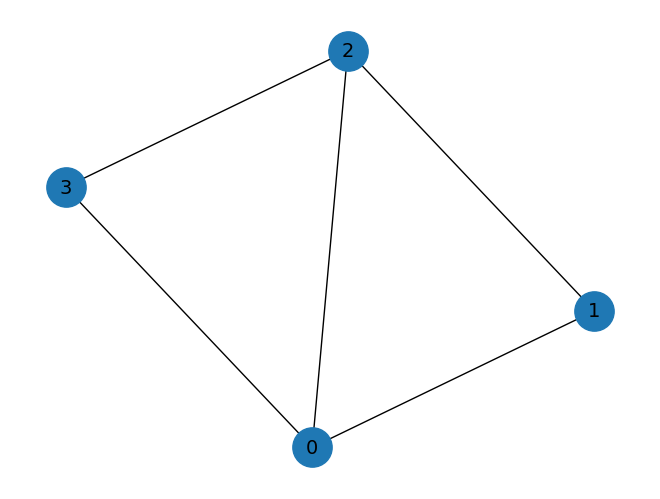

In [26]:
G = nx.Graph()

edges = [
    (0, 1),
    (1, 2),
    (2, 3),
    (3, 0),
    (0, 2)
]

G.add_edges_from(edges)

pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True, node_size=800, font_size=14)

plt.show()

Con la función para Max-Cut que hemos usado ahorita, podemos encontrarlo rapidamente, y compararemos esa respuesta con la que encontremos con QUBO

In [27]:
max_cut_valor, max_cut_assignment = max_cut_fuerza_bruta(G)

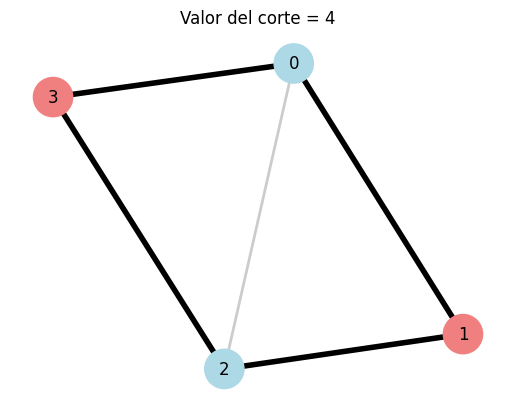

In [28]:
draw_cut(G, max_cut_assignment)

Veamos si esto es cierto. Usaremos VQE para corroborarlo. 

#### De QUBO a Ising

Cambiamos las variables por $x_i=\frac{1-z_i}{2}$ con $z_i\in\{-1,1\}$

Notemos como una arista la podemos escribir como $C_{ij}= \frac{1-z_iz_j}{2}$, pues vale 0 si los nodos estan en la misma posición y 1 si estan en posiciones diferentes.

y de aquí, sabemos que el Hamiltoniano Ising queda como 

$$
H(z)=-\sum_{(i,j)\in E}\frac{1-z_iz_j}{2}
$$
$$
=-\frac{|E|}{2}+\frac{1}{2}\sum_{(i,j)\in E}z_iz_j
$$

lo cual ademas queda como 
$$
H(z)=-\frac{5}{2}+\frac{1}{2}(z_0z_1+z_1z_2+z_2z_3+z_3z_0+z_0z_2)
$$

Ahora, la constante la podemos obviar y el hamiltoniano se reduze a matrices de Paulli Z que se aplican en el sistema. Vamos a ver si Pennylane nos puede ayudar con esto



In [36]:
import pennylane as qml
from pennylane import numpy as pnp

n_qubits = 4 #Número de qubits igual al número de nodos en el grafo

coeffs = [] #Creamos una lista para almacenar los coeficientes de cada término del Hamiltoniano, que en este caso serán 0.5 para cada conexión del grafo
observables = [] #Creamos una lista para almacenar los términos del Hamiltoniano, que en este caso serán productos de operadores de Pauli Z para cada par de nodos conectados por una arista en el grafo

#Construimos el Hamiltoniano de costo para el problema Max-Cut utilizando las conexiones del grafo
for i, j in edges: 
    coeffs.append(0.5)  #Agregamos el coeficiente 0.5 para cada término del Hamiltoniano
    observables.append(qml.PauliZ(i) @ qml.PauliZ(j)) #Agregamos el término de interacción entre los qubits i y j utilizando el operador de Pauli Z para cada nodo conectado por una arista en el grafo

H_cost = qml.Hamiltonian(coeffs, observables)

H_cost

(
    0.5 * (Z(0) @ Z(1))
  + 0.5 * (Z(1) @ Z(2))
  + 0.5 * (Z(2) @ Z(3))
  + 0.5 * (Z(3) @ Z(0))
  + 0.5 * (Z(0) @ Z(2))
)

¿Y como encontramos estados base de un hamiltoniano?

Exactamente, VQE

In [37]:
dev = qml.device("default.qubit", wires=n_qubits)

def ansatz(params):
    # Primera capa de rotaciones
    for i in range(n_qubits): #Iteramos sobre cada qubit para aplicar una rotación RY con el ángulo dado por los parámetros de entrada
        qml.RY(params[0, i], wires=i) 

    # Capa de entrelazamiento
    qml.CNOT(wires=[0, 1])
    qml.CNOT(wires=[1, 2])
    qml.CNOT(wires=[2, 3])
    qml.CNOT(wires=[3, 0])

    # Segunda capa de rotaciones
    for i in range(n_qubits):
        qml.RY(params[1, i], wires=i) 

In [38]:
@qml.qnode(dev)
def cost_circuit(params):
    ansatz(params)
    return qml.expval(H_cost)

In [39]:
params = pnp.random.uniform(
    low=0,
    high=2*np.pi,
    size=(2, n_qubits),
    requires_grad=True
)

optimizer = qml.AdamOptimizer(stepsize=0.1) #Usamos optimizador Adam, tu puedes experimentar con otros optimizadores disponibles en PennyLane, como GradientDescentOptimizer, MomentumOptimizer, etc., para ver cuál funciona mejor para tu problema específico.

energy_history = [] #Creamos una lista para almacenar el valor de la energía (costo) en cada iteración del proceso de optimización, lo que nos permitirá visualizar cómo evoluciona el costo a lo largo del tiempo y evaluar la convergencia del algoritmo de optimización utilizado.

steps = 150

for step in range(steps): #Iteramos durante un número determinado de pasos para optimizar los parámetros del circuito
    params, energy = optimizer.step_and_cost(cost_circuit, params)
    energy_history.append(energy) #Agregamos el valor de la energía (costo) calculado en esta iteración a la lista energy_history para poder analizar su evolución a lo largo del proceso de optimización.

    if step % 10 == 0:
        print(f"Iteración {step:3d} | Energía = {energy:.6f}") #Imprime el número de iteración y el valor de la energía (costo) cada 10 iteraciones para monitorear el progreso del proceso de optimización.

print("\nEnergía final:", energy_history[-1])
print("Parámetros óptimos:")
print(params)

Iteración   0 | Energía = -0.688891
Iteración  10 | Energía = -1.022682
Iteración  20 | Energía = -1.254110
Iteración  30 | Energía = -1.469144
Iteración  40 | Energía = -1.487811
Iteración  50 | Energía = -1.491274
Iteración  60 | Energía = -1.496817
Iteración  70 | Energía = -1.498771
Iteración  80 | Energía = -1.499625
Iteración  90 | Energía = -1.499891
Iteración 100 | Energía = -1.499982
Iteración 110 | Energía = -1.499989
Iteración 120 | Energía = -1.499994
Iteración 130 | Energía = -1.499997
Iteración 140 | Energía = -1.499999

Energía final: -1.4999995003673923
Parámetros óptimos:
[[ 6.28334198e+00  5.57467361e+00 -3.02976976e-04  8.17385601e-04]
 [-2.71423148e-04  3.14211709e+00  6.28270047e+00  3.14179569e+00]]


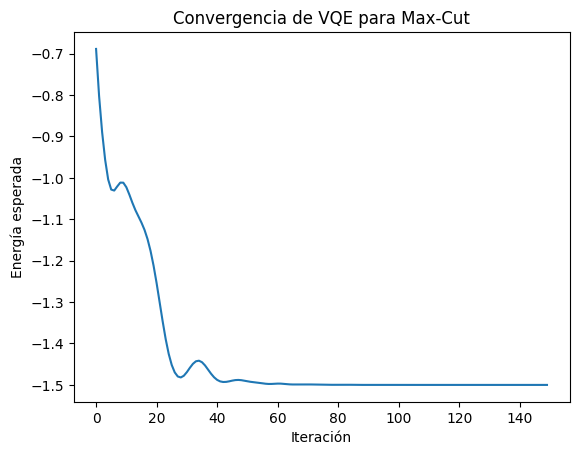

In [40]:
plt.plot(energy_history)
plt.xlabel("Iteración")
plt.ylabel("Energía esperada")
plt.title("Convergencia de VQE para Max-Cut")
plt.show()

Con esto nosotro ya hemos visto que basicamente nuestro algoritmo encontro el valor para el cual la energía es mínima, pero no esta completo. 

Buscamos no solamente el eigenvalor, si no tambien el eigenvector, y en esta ocasión necesitaremos recuperar los shots para ello y medir el estao cuantico

Usaremos un dispositivo diferente para ello


In [34]:
dev_counts = qml.device("default.qubit", wires=n_qubits, shots=1000)

@qml.qnode(dev_counts)
def counts_circuit(params): #Usamos los parametros optimizados
    ansatz(params) 
    return qml.counts(wires=range(n_qubits)) #Obtenemos el conteo de resultados para cada posible resultado de medición en los qubits.

c:\Users\the_b\miniconda3\envs\pennylane-env\Lib\site-packages\pennylane\devices\device_api.py:201: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


In [35]:
counts = counts_circuit(params) #Obtenemos el conteo de resultados para cada posible resultado de medición en los qubits utilizando los parámetros optimizados del circuito.

counts

{np.str_('1010'): np.int64(1000)}